##Exercise: Building a Fully Connected Network (FCN) for Devnagari Digit Classification.

##Task 1: Data Preparation

Loading the Data

In [ ]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical

img_size = 28

def load_data(folder):
    images = []
    labels = []
    classes = sorted(os.listdir(folder))

    for class_name in classes:
        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue

        label = int(class_name.split('_')[1])

        for file in os.listdir(class_path):
            file_path = os.path.join(class_path, file)
            try:
                img = Image.open(file_path).convert('L')
                img = img.resize((28, 28))
                img = np.array(img, dtype=np.float32) / 255.0
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Skipping {file_path}: {e}")

    return np.array(images), np.array(labels)

x_train, y_train = load_data("/content/drive/MyDrive/AI and ML/DevanagariHandwrittenDigitDataset/Train")
x_test, y_test = load_data("/content/drive/MyDrive/AI and ML/DevanagariHandwrittenDigitDataset/Test")

# one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

##Task 2: Build the FCN Model

Model Architecture

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(64, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

##Task 3: Compile the Model

Model Compilation

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

##Task 4: Train the Model

Model Training

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4768 - loss: 1.5736 - val_accuracy: 0.0000e+00 - val_loss: 7.6083
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8103 - loss: 0.5721 - val_accuracy: 0.0000e+00 - val_loss: 8.4228
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9207 - loss: 0.2903 - val_accuracy: 0.0000e+00 - val_loss: 9.4213
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9454 - loss: 0.1960 - val_accuracy: 0.0000e+00 - val_loss: 9.8541
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9590 - loss: 0.1477 - val_accuracy: 0.0000e+00 - val_loss: 10.0161
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9665 - loss: 0.1182 - val_accuracy: 0.0000e+00 - val_loss: 10.1498
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9730 - loss: 0.0985 - val_accuracy: 0.0000e+00 - val_loss: 10.4944
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9777

##Task 5: Evaluate the Model

Model Evaluation

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7833 - loss: 2.5583
Test Loss: 2.558316946029663
Test Accuracy: 0.7833333611488342


##Task 6: Save and Load the Model

Model Saving and Loading

In [ ]:
model.save("devnagari_fcn.h5")

from tensorflow.keras.models import load_model
loaded_model = load_model("devnagari_fcn.h5")

loss, acc = loaded_model.evaluate(x_test, y_test, verbose=1)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7833 - loss: 2.5583
Loaded Model Accuracy: 0.7833333611488342


##Task 7: Predictions

Making Predictions

In [ ]:
predictions = loaded_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted labels:", predicted_labels[:10])
print("Actual labels:", np.argmax(y_test[:10], axis=1))

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted labels: [0 0 0 0 0 0 0 0 0 0]
Actual labels: [0 0 0 0 0 0 0 0 0 0]


##Graph

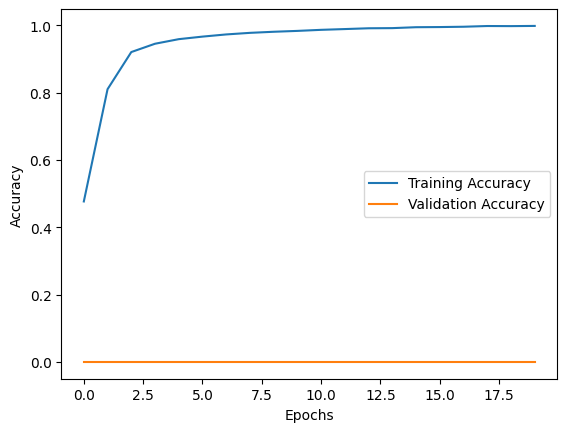

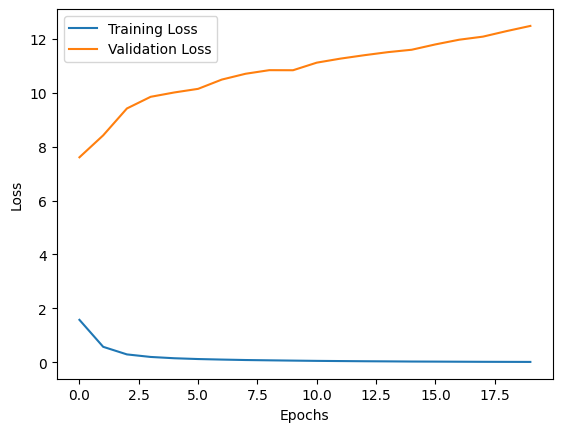

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()